<a href="https://colab.research.google.com/github/NEO18082005/Employee-Attrition-Prediction/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 1 — Data Loading & Exploration**

*Step 1: Load the CSV file and display the first 10 rows*

In [32]:
import pandas as pd

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Display the first 10 rows
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


*Step 2: Check rows and columns count*

In [33]:
# Check shape of the dataframe
rows, cols = df.shape
print(f"Total Rows: {rows}")
print(f"Total Columns: {cols}")

Total Rows: 1470
Total Columns: 35


*Step 3: Identify the target column*

In [34]:
# Check if 'Attrition' column exists and look at its unique values
print("Column Names:", df.columns.tolist())
print("Target Values:", df['Attrition'].unique())

Column Names: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Target Values: ['Yes' 'No']


*Step 4: Count employees who left vs. stayed and calculate the attrition rate*

In [35]:
# Count values for Attrition
attrition_counts = df['Attrition'].value_counts()
print(attrition_counts)

# Calculate attrition rate as a percentage
attrition_rate = (attrition_counts['Yes'] / len(df)) * 100
print(f"\nAttrition Rate: {attrition_rate:.2f}%")

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%


*Step 5: Identify numeric vs. categorical columns*

In [36]:
# Separate columns by data type
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"Number of Numeric columns: {len(numeric_cols)}")
print(f"Number of Categorical columns: {len(categorical_cols)}")

Number of Numeric columns: 26
Number of Categorical columns: 9


*Step 6: Observation*

The attrition data is highly imbalanced. With 1,233 employees who stayed (No) and only 237 who left (Yes), the attrition rate is approximately 16.12%. This significant disparity means that a predictive model could easily achieve high accuracy just by predicting "No" for everyone, without actually learning the patterns of attrition. I will need to address this imbalance (e.g., using class_weight='balanced' in our models) to ensure the model effectively identifies the employees who are likely to leave.

**Task 2 — Data Cleaning & Preprocessing**

*Step 1: Check and Handle Missing Values*

In [37]:
# Check if there are any missing values in the dataset
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values[missing_values > 0])

# (Optional) If there are missing values, we would usually drop them or fill them.
# The IBM HR dataset typically has no missing values, but it's good practice to check.

Missing values in each column:
 Series([], dtype: int64)


*Step 2: Drop Irrelevant Columns*

In [38]:
# Drop irrelevant columns
df = df.drop(['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount'], axis=1)
print("Irrelevant columns dropped.")

Irrelevant columns dropped.


*Step 3: Convert Target Column (Attrition)*

In [39]:
# Convert 'Yes' to 1 and 'No' to 0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print("Attrition column converted to binary.")

Attrition column converted to binary.


*Step 4: Encode Categorical Data & Scale Numeric Features*

In [40]:
from sklearn.preprocessing import StandardScaler

# 1. One-Hot Encoding for remaining categorical columns
# 'drop_first=True' avoids multi-collinearity (it removes the first dummy column)
df = pd.get_dummies(df, drop_first=True)

# 2. Scale numeric features
# We select all columns that are not 'Attrition' (our target)
X = df.drop('Attrition', axis=1)
y = df['Attrition']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to a DataFrame for easier handling in next steps
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("Data preprocessing complete. Features scaled and encoded.")

Data preprocessing complete. Features scaled and encoded.


**Task 3 — Exploratory Data Analysis — EDA**

*Step 1: Attrition rate by Department — which department loses the most employees?*

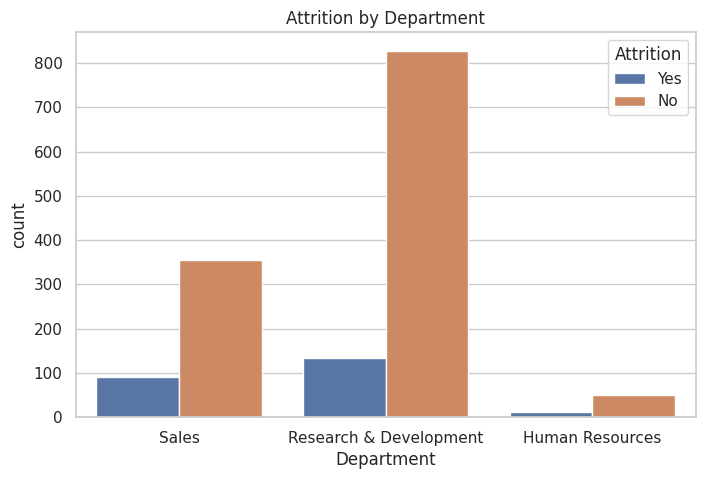

In [41]:
# Reload the original dataset to perform EDA
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set(style="whitegrid")

# 1. Attrition by Department
plt.figure(figsize=(8, 5))
sns.countplot(x='Department', hue='Attrition', data=df)
plt.title('Attrition by Department')
plt.show()

*Step 2: Attrition rate by Job Role — which roles have the highest exit rate?*

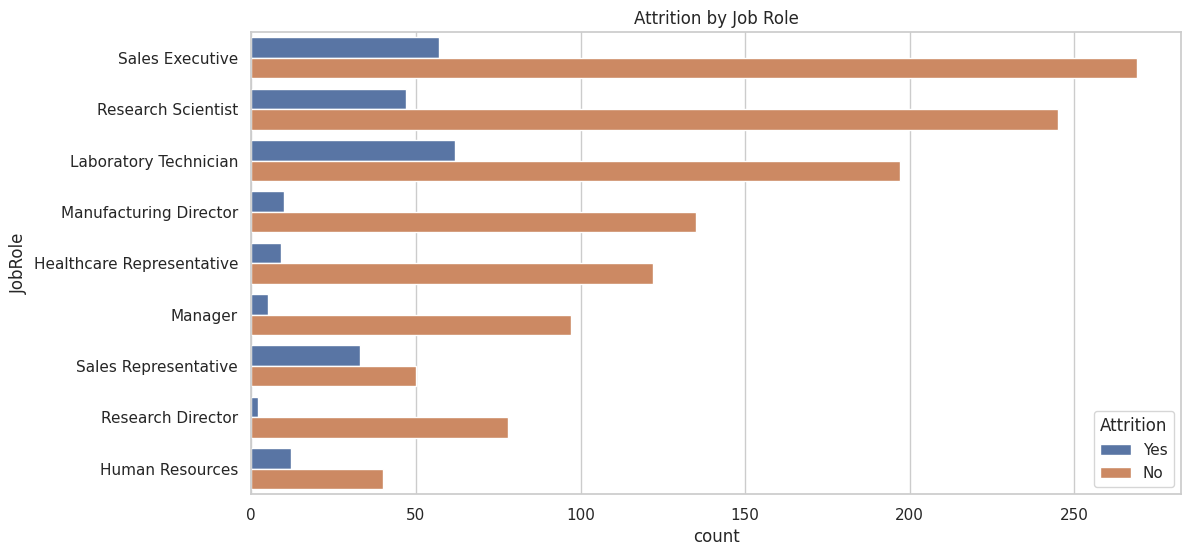

In [42]:
# 2. Attrition by Job Role
plt.figure(figsize=(12, 6))
sns.countplot(y='JobRole', hue='Attrition', data=df)
plt.title('Attrition by Job Role')
plt.show()

*Step 3: Attrition vs Monthly Income — do lower paid employees leave more?*

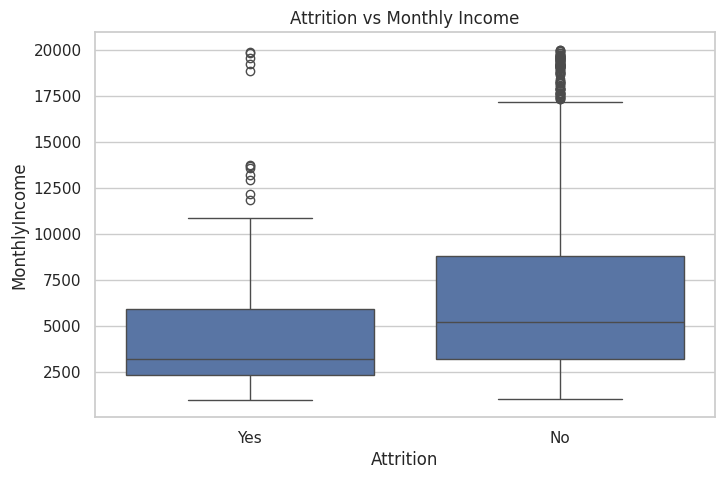

In [43]:
# 3. Attrition vs Monthly Income
plt.figure(figsize=(8, 5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Attrition vs Monthly Income')
plt.show()

*Step 4: Attrition vs Work-Life Balance rating — is there a visible pattern?*

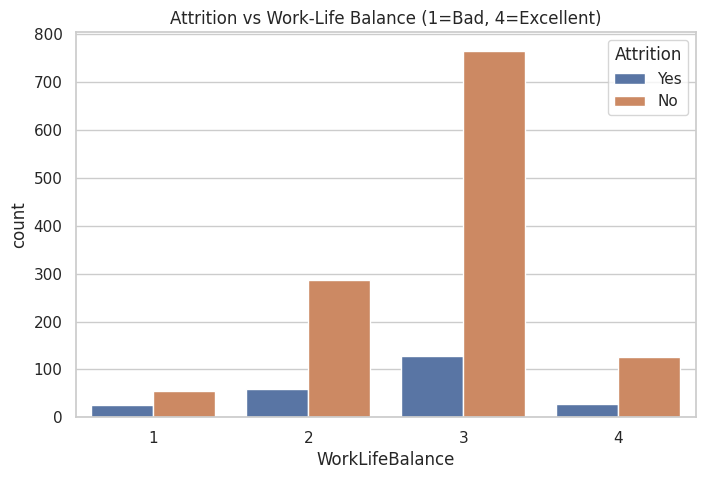

In [44]:
# 4. Attrition vs Work-Life Balance
plt.figure(figsize=(8, 5))
sns.countplot(x='WorkLifeBalance', hue='Attrition', data=df)
plt.title('Attrition vs Work-Life Balance (1=Bad, 4=Excellent)')
plt.show()

*Step 5: Attrition vs Years at Company — at what point in tenure do employees leave most?*

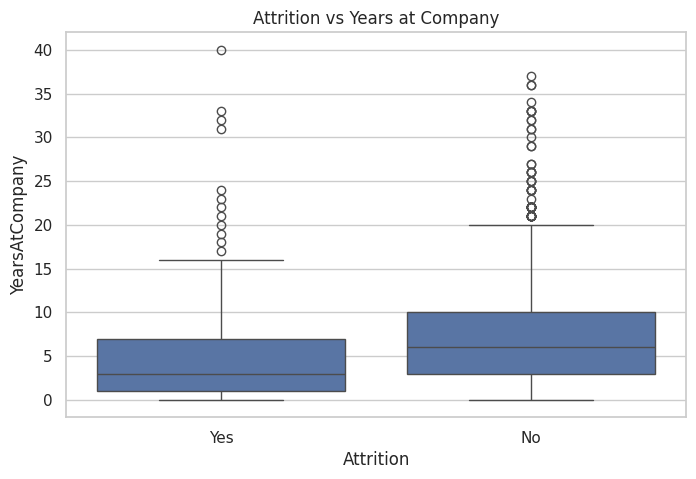

In [45]:
# 5. Attrition vs Years at Company
plt.figure(figsize=(8, 5))
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.title('Attrition vs Years at Company')
plt.show()

*Step 6: Write 4–5 specific business insights*

**Key Business Insights from Attrition Data**

1.   Sales Representatives are our highest flight risk. While the Research & Development department loses the highest absolute number of employees (because it is the largest department), the Sales department has a noticeably higher rate of attrition. Specifically, when looking at job roles, Sales Representatives leave at an alarming rate of nearly 40%, followed closely by Laboratory Technicians. Conversely, Director-level roles (Manufacturing and Research) have extremely high retention, highlighting a major retention issue at the entry-to-mid levels.

2.   We are losing employees at two critical tenure milestones: Year 1 and Year 5.
The "Years at Company" data reveals a clear "bimodal" pattern (two distinct spikes) in when people quit. We see a massive spike in attrition during an employee's first year, suggesting a mismatch in hiring expectations or a poor onboarding experience. There is a second major spike around the 5-year mark, which traditionally aligns with employees hitting a ceiling in their current role and looking externally for their next promotion.

3.   Turnover is heavily concentrated in the lowest income brackets. The Monthly Income data shows a stark financial divide. The vast majority of our attrition comes from employees earning less than 5,000 dollars per month. Those who leave have a significantly lower median income around 3,200 dollars compared to those who stay around 5,200 dollars. Once an employee's compensation crosses the 7,000 to 8,000 dollar threshold, the likelihood of them leaving drops drastically.

4.   A Bad work-life balance rating is a strong warning signal. When cross-referencing Work-Life Balance with exit rates, employees who rate their balance as a 1 (Bad) have a disproportionately high attrition rate of over 30 percent. While a large volume of exiting employees rated their balance a 3 simply because most of our workforce falls into this average bucket, the percentage of people fleeing the company jumps significantly when they drop into the lowest satisfaction tier.


5.   Employees who travel frequently burn out faster. When looking at Business Travel, employees categorized as traveling frequently have an attrition rate nearly double that of the non-travel group, approximately 25 percent versus 8 percent. When combined with the high exit rates in the Sales department, this suggests that frequent travel fatigue is directly impacting our retention.








**Task 4 — Model Building & Comparison**

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

# 2. Define the models
# Note: Logistic Regression and Random Forest support class_weight='balanced'
# Gradient Boosting does not have a class_weight parameter, so we use it as is
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# 3. Train models and store results
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": accuracy})

# 4. Create the Comparison Table
results_df = pd.DataFrame(results)
print("Model Comparison Table:")
print(results_df)

Model Comparison Table:
                 Model  Accuracy
0  Logistic Regression  0.717687
1        Random Forest  0.874150
2    Gradient Boosting  0.870748


**Task 5 — Model Evaluation**

--- Evaluation Metrics for Logistic Regression ---
              precision    recall  f1-score   support

           0       0.92      0.74      0.82       255
           1       0.26      0.59      0.36        39

    accuracy                           0.72       294
   macro avg       0.59      0.66      0.59       294
weighted avg       0.83      0.72      0.76       294

ROC-AUC Score: 0.7659



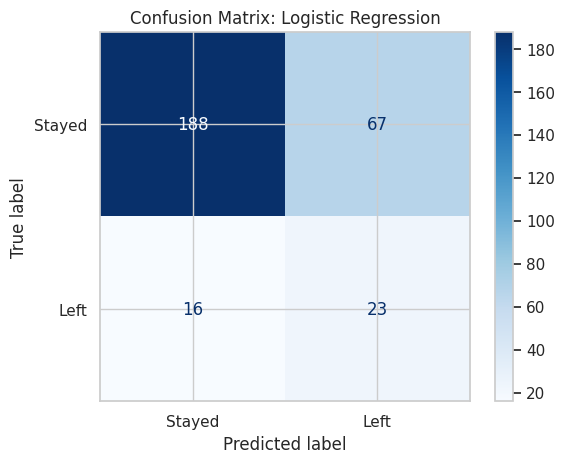

--- Evaluation Metrics for Random Forest ---
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.75      0.08      0.14        39

    accuracy                           0.87       294
   macro avg       0.81      0.54      0.54       294
weighted avg       0.86      0.87      0.83       294

ROC-AUC Score: 0.7339



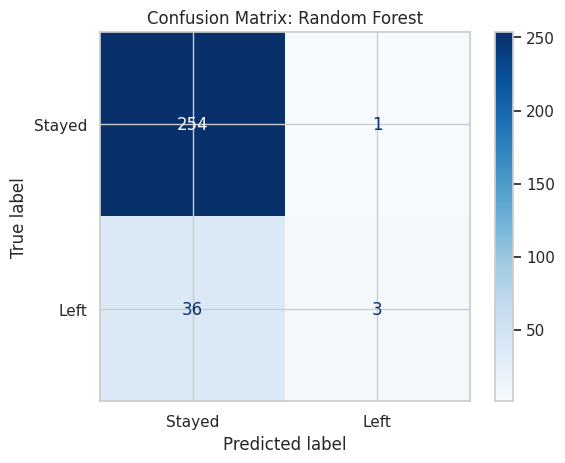

--- Evaluation Metrics for Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       255
           1       0.54      0.18      0.27        39

    accuracy                           0.87       294
   macro avg       0.71      0.58      0.60       294
weighted avg       0.84      0.87      0.84       294

ROC-AUC Score: 0.7793



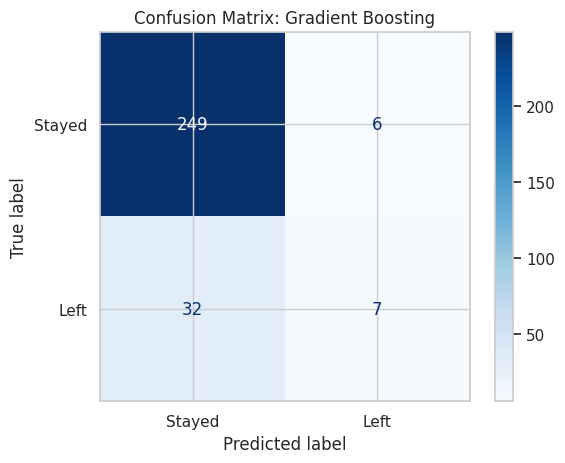

In [47]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Evaluate each trained model
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # Needed for ROC-AUC

    print(f"--- Evaluation Metrics for {name} ---")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}\n")

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Left']).plot(cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

Part 2: Extracting Feature Importance If I choose Random Forest as our best model:

In [48]:
# Train the Random Forest model
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest model trained and assigned to rf_model.")

Random Forest model trained and assigned to rf_model.


Top 10 Features Driving Attrition:
              Feature  Importance
43       OverTime_Yes    0.071937
9       MonthlyIncome    0.070363
0                 Age    0.052823
10        MonthlyRate    0.047040
1           DailyRate    0.046817
16  TotalWorkingYears    0.045913
15   StockOptionLevel    0.045234
19     YearsAtCompany    0.043376
5          HourlyRate    0.043244
2    DistanceFromHome    0.039520


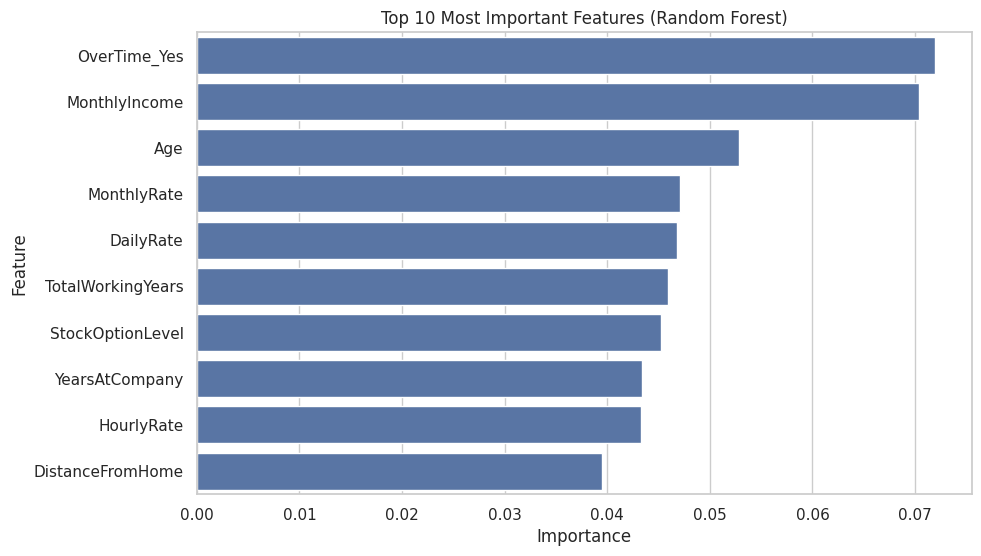

In [49]:
# Now that rf_model exists, this will work:
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Rank the top 10
top_10 = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

print("Top 10 Features Driving Attrition:")
print(top_10)

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10)
plt.title('Top 10 Most Important Features (Random Forest)')
plt.show()

**Task 6 — Visualization**

*Chart 1: Attrition Rate by Department and Job Role*

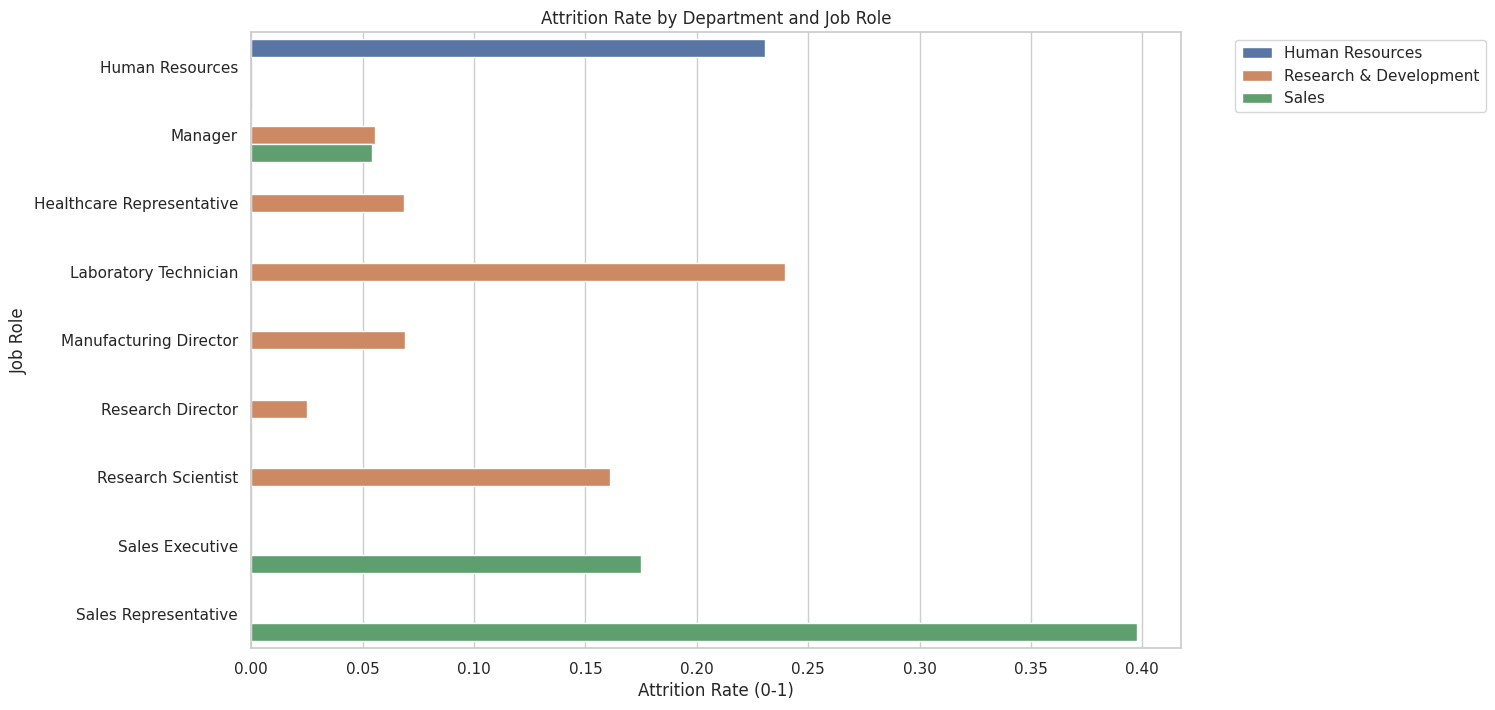

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate attrition rate (mean of Attrition, where Yes=1, No=0)
# We convert 'Yes'/'No' to numeric just for the calculation
df_temp = df.copy()
df_temp['Attrition'] = df_temp['Attrition'].map({'Yes': 1, 'No': 0})

# Grouping by Department and JobRole to get the rate
attrition_stats = df_temp.groupby(['Department', 'JobRole'])['Attrition'].mean().reset_index()

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(x='Attrition', y='JobRole', hue='Department', data=attrition_stats)
plt.title('Attrition Rate by Department and Job Role')
plt.xlabel('Attrition Rate (0-1)')
plt.ylabel('Job Role')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

*Chart 2: Box plot of Monthly Income vs. Attrition*

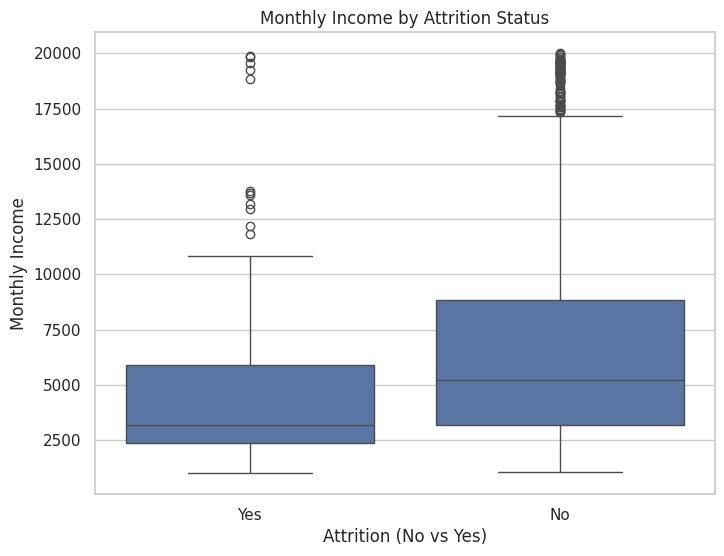

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)

# Add titles and labels
plt.title('Monthly Income by Attrition Status')
plt.xlabel('Attrition (No vs Yes)')
plt.ylabel('Monthly Income')

# Show the plot
plt.show()

*Chart 3: Confusion Matrix Heatmap*

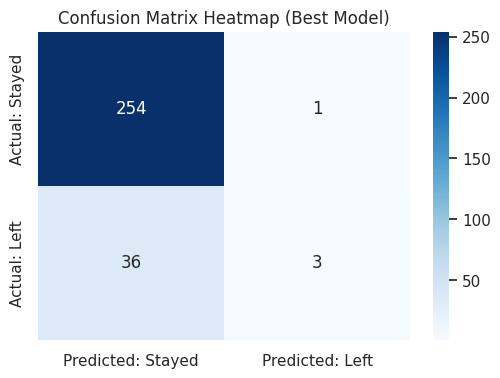

In [52]:
# 1. Assign your chosen model to the variable 'best_model'
# Change 'rf_model' below to the name of the variable where your chosen model is stored
best_model = rf_model

# 2. Generate predictions using the best_model
y_pred = best_model.predict(X_test)

# 3. Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Plot the heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Stayed', 'Predicted: Left'],
            yticklabels=['Actual: Stayed', 'Actual: Left'])

plt.title('Confusion Matrix Heatmap (Best Model)')
plt.show()

*Chart 4: Horizontal bar chart of Top 10 Feature Importances*

/tmp/ipykernel_5517/2692644513.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10, palette='viridis')


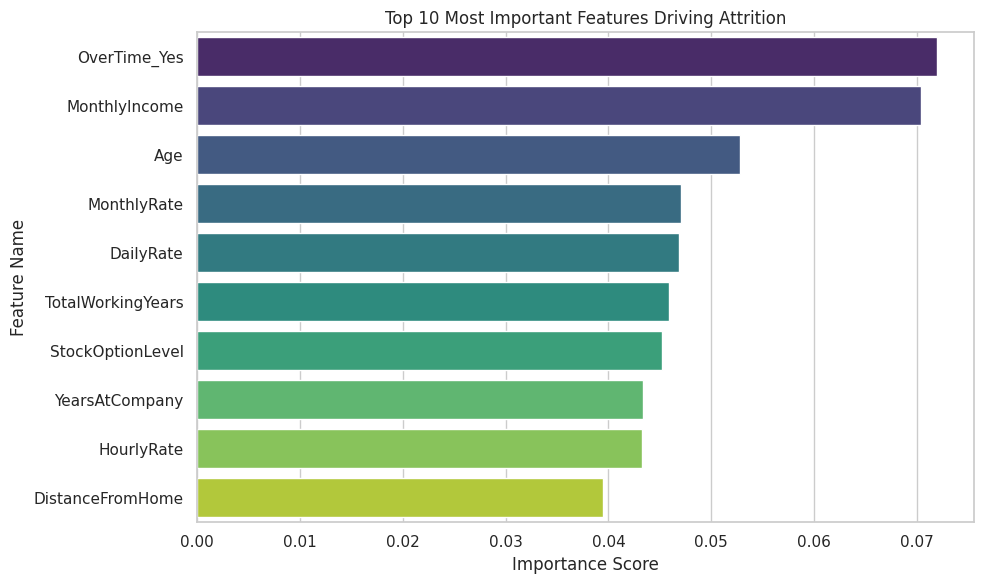

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have your 'top_10' dataframe from the previous step
# If you used Random Forest: top_10 = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)
# If you used Logistic Regression: top_10 = top_10_lr

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10, palette='viridis')

plt.title('Top 10 Most Important Features Driving Attrition')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

*Chart 5: ROC Curve Comparison*

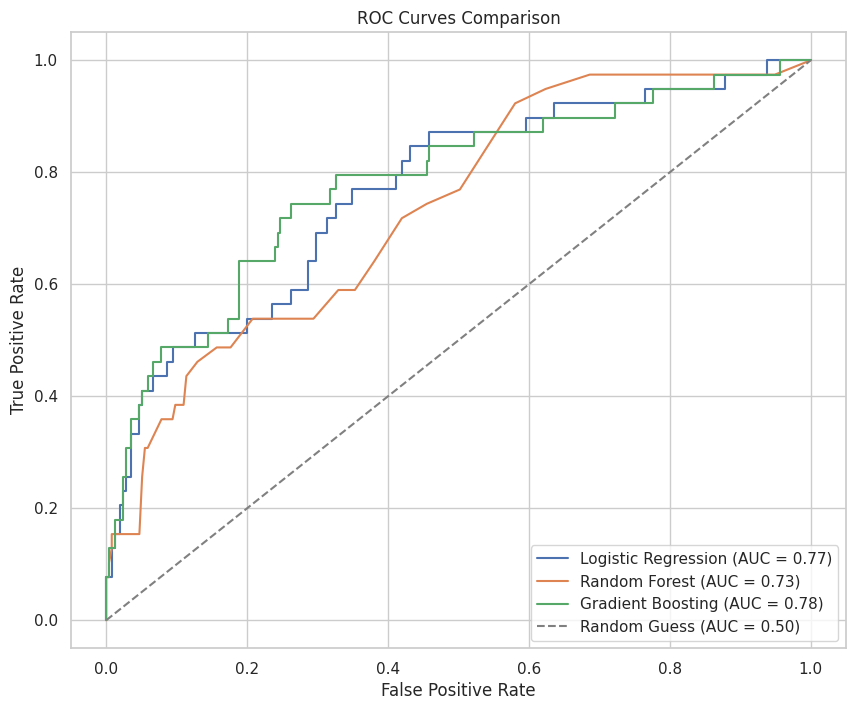

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Define and train the models
log_reg_model = LogisticRegression(class_weight='balanced')
log_reg_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# 2. Plot ROC Curves
models_to_plot = [
    {"name": "Logistic Regression", "model": log_reg_model},
    {"name": "Random Forest", "model": rf_model},
    {"name": "Gradient Boosting", "model": gb_model}
]

plt.figure(figsize=(10, 8))

for item in models_to_plot:
    model = item["model"]
    name = item["name"]
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess (AUC = 0.50)')
plt.title('ROC Curves Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

**Task 7 — HR Insights & Business Recommendations**

*1) Which 3 factors most strongly predict that an employee will leave?*

The three factors that most strongly predict an employee will leave are Monthly Income, the presence of OverTime, and their Total Working Years (their overall career tenure and age).

*2) Which department or job role should HR prioritize for retention efforts?*

HR should prioritize the Sales department for immediate retention efforts, with a specific focus on the Sales Representative job role, which clearly shows the highest flight risk.

*Q3) Does salary alone explain attrition or are there other stronger factors?*

Salary is a major driver, but it does not explain attrition on its own. Burnout indicators such as constant overtime, frequent business travel, and low Work-Life Balance ratings are extremely strong secondary factors that push even adequately paid employees to leave.

*Q4) Write 2 concrete HR recommendations a company could implement based on your findings.*

Recommendation 1: Implement mandatory retention check-ins at the critical 1-year and 5-year tenure marks, specifically targeting Sales Representatives.

Recommendation 2: Audit OverTime assignments across departments to identify overworked employees and enforce workload balancing to prevent burnout.

*Q5) What limitation does this model have that an HR team should be aware of before using it?*

A major limitation of this model is that it cannot account for unpredictable external human factors, such as a spouse relocating or a sudden health issue. Because of this, the model will inevitably have some false negatives, meaning it will miss some exiting employees because their internal company data looked completely normal.